In [1]:
import tensorflow as tf

In [2]:
import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
from tensorflow.keras import layers
import time

from IPython import display


This cell imports various libraries required for the GAN implementation:
- `glob`: Used for finding pathnames matching a specified pattern.
- `imageio`: A library for reading and writing image data.
- `matplotlib.pyplot`: A plotting library used for visualizing the generated images and loss curves.
- `numpy`: The fundamental package for numerical computation in Python, often used for array manipulation.
- `os`: Provides a way of using operating system dependent functionality, like file paths.
- `PIL` (Pillow): The Python Imaging Library, used for image processing.
- `tensorflow.keras.layers`: Provides the building blocks for neural networks within TensorFlow's Keras API.
- `time`: Used for timing operations, especially during the training loop.
- `IPython.display`: Used in Jupyter/Colab notebooks to display various rich outputs, like clearing output for animation.

### **Load Dataset**

In [3]:
(train_images, train_labels), (_, _) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


This cell loads the MNIST dataset, which is a classic dataset of handwritten digits. It's split into training and testing sets. Here, we only load the training images (`train_images`) and labels (`train_labels`), and discard the test set as it's not needed for GAN training in this context.

In [4]:
train_images.shape

(60000, 28, 28)

This cell displays the shape of the `train_images` array, which is `(60000, 28, 28)`. This indicates there are 60,000 training images, each being 28 pixels by 28 pixels.

In [5]:

train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5  # Normalize the images to [-1, 1]
BUFFER_SIZE = 60000  # total images
BATCH_SIZE = 256
# Batch and shuffle the data, Converts NumPy array into a TensorFlow Dataset
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

This cell performs preprocessing steps on the training data:
- **Reshaping**: `train_images` are reshaped from `(60000, 28, 28)` to `(60000, 28, 28, 1)`. The `1` represents the single color channel (grayscale) of the images.
- **Normalization**: Pixel values, originally from 0-255, are normalized to the range `[-1, 1]`. This is a common practice in GANs, particularly when the generator's output layer uses a `tanh` activation function, which also outputs values in this range.
- **Buffering and Batching**: The data is converted into a `tf.data.Dataset`, shuffled using `BUFFER_SIZE` to randomize the order of images, and then batched into groups of `BATCH_SIZE` (256) for efficient training.

### **Generator**

In [6]:
def make_generator_model():
    model = tf.keras.Sequential()
    # first layer is dense adding vector of values
    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(100,)))#no bias is used
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())#[-1,1] inorder to preserve the negative values we used leakyRelu

    model.add(layers.Reshape((7, 7, 256)))
    assert model.output_shape == (None, 7, 7, 256) # Note: None is the batch size

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    assert model.output_shape == (None, 7, 7, 128)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 14, 14, 64)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    assert model.output_shape == (None, 28, 28, 1)

    return model

This Python function, `make_generator_model()`, defines the architecture of the Generator network. The Generator's role is to take a random noise vector as input and transform it into an image that resembles a real MNIST digit.

**Architecture Breakdown:**
- **Dense Layer**: Starts by transforming a 100-dimensional input noise vector into a higher-dimensional tensor (7x7x256). `use_bias=False` is used because `BatchNormalization` will handle the biases.
- **BatchNormalization**: Normalizes the activations of the previous layer, stabilizing and speeding up training.
- **LeakyReLU**: An activation function that allows a small, non-zero gradient when the unit is not active, helping to prevent 'dying ReLU' problems.
- **Reshape**: Reshapes the 1D output of the Dense layer into a 3D tensor (7x7 pixels with 256 channels), which is suitable for convolutional layers.
- **Conv2DTranspose Layers (3x)**: Also known as 'deconvolutional' or 'upsampling' layers. These layers are used to increase the spatial dimensions of the input. They progressively upsample the image from 7x7 to 14x14, and finally to 28x28, while also reducing the number of channels. Each is followed by `BatchNormalization` and `LeakyReLU`.
- **Final `Conv2DTranspose` with `tanh` activation**: The last layer uses a `tanh` activation function to output pixel values in the range `[-1, 1]`, matching the normalization of the real training images.

**Sample image**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


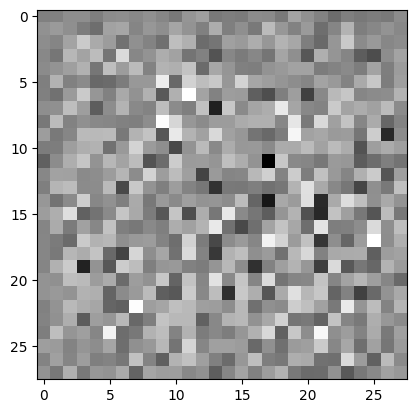

In [7]:
generator = make_generator_model()

noise = tf.random.normal([1, 100])
generated_image = generator(noise, training=False)

plt.imshow(generated_image[0, :, :, 0], cmap='gray')#sample image

This cell demonstrates the functionality of the `generator` model:
- It instantiates the `generator` using `make_generator_model()`.
- A random noise vector (`noise`) of shape `[1, 100]` is created, representing a single input for the generator.
- The `generator` then takes this `noise` and produces a `generated_image`. `training=False` is set to ensure that layers like `BatchNormalization` run in inference mode.
- Finally, `matplotlib.pyplot.imshow()` displays this generated image. The image data is indexed (`[0, :, :, 0]`) to select the first (and only) image in the batch and its single channel, and `cmap='gray'` specifies a grayscale colormap.

### **Discriminator**

In [8]:
def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

This Python function, `make_discriminator_model()`, defines the architecture of the Discriminator network. The Discriminator's role is to classify input images as either 'real' (coming from the MNIST dataset) or 'fake' (generated by the Generator).

**Architecture Breakdown:**
- **Conv2D Layers (2x)**: These are standard convolutional layers used for feature extraction and downsampling. They take a 28x28x1 image as input and apply filters to learn spatial hierarchies of patterns.
- **LeakyReLU**: An activation function used after each convolutional layer.
- **Dropout**: A regularization technique where a fraction of neurons are randomly ignored during training. This helps prevent overfitting.
- **Flatten**: Converts the 3D output of the convolutional layers (e.g., 7x7x128) into a 1D vector.
- **Dense Layer**: The final layer outputs a single value, representing the discriminator's confidence that the input image is real. There is no explicit activation function here, as the `BinaryCrossentropy` loss function will handle logits (raw scores) directly.

In [9]:
discriminator = make_discriminator_model()
decision = discriminator(generated_image)
print (decision)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


tf.Tensor([[-0.00215055]], shape=(1, 1), dtype=float32)


This cell demonstrates the functionality of the `discriminator` model:
- It instantiates the `discriminator` using `make_discriminator_model()`.
- It then passes the `generated_image` (created earlier by the generator) through the `discriminator`.
- The output `decision` is printed, which is a single floating-point value. A positive value would generally indicate the discriminator thinks the image is real, and a negative value indicates it thinks the image is fake. Since the discriminator hasn't been trained yet, this value is essentially random.

In [10]:
# Create an instance of the Generator and Discriminator
generator = make_generator_model()
discriminator = make_discriminator_model()

This cell re-instantiates fresh instances of both the `generator` and `discriminator` models. This is important to ensure that their weights are initialized randomly before starting the actual training process, rather than carrying over weights from the previous sample generation/testing steps.

In [11]:
# This method returns a helper function to compute cross entropy loss
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

This cell initializes the `BinaryCrossentropy` loss function from TensorFlow Keras. This loss function is suitable for binary classification tasks (like distinguishing real vs. fake images). The `from_logits=True` argument is crucial because the discriminator's final dense layer outputs raw scores (logits) rather than probabilities, and this setting ensures the loss function applies a sigmoid activation internally for numerical stability.

### **Learns to distinguish real images from fake ones**

In [12]:
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output) #1
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)#0
    total_loss = real_loss + fake_loss
    return total_loss

The `discriminator_loss` function calculates the total loss for the discriminator. It consists of two parts:
- **`real_loss`**: How well the discriminator classifies real images as real (labels them as 1).
- **`fake_loss`**: How well the discriminator classifies fake images (generated by the generator) as fake (labels them as 0).

The goal of the discriminator is to minimize this combined loss, meaning it wants to correctly identify both real and fake images.

In [13]:
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

The `generator_loss` function calculates the loss for the generator. The generator's goal is to fool the discriminator. Therefore, its loss is calculated by how well the discriminator classifies the *fake* images it produces as *real* (labels them as 1). The generator wants to minimize this loss, meaning it wants to generate images that the discriminator mistakenly believes are real.

### **Optimizer**

In [14]:
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

This cell sets up the optimizers for both the generator and discriminator networks. Both use the `Adam` optimizer, which is a popular choice for deep learning models due to its adaptive learning rate capabilities.
- **Learning Rate (`2e-4` or 0.0002)**: A common learning rate for GAN training.
- **Beta 1 (`beta_1=0.5`)**: This parameter controls the exponential decay rate for the first moment estimates (mean of the gradients). A value of 0.5 is often used in GANs to help stabilize training.

In [15]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)


This cell configures checkpointing, which is a mechanism to save the model's progress during training. This allows you to resume training from a saved point or load the trained models later.
- `checkpoint_dir`: Specifies the directory where checkpoints will be saved.
- `checkpoint_prefix`: Defines the file prefix for the checkpoint files.
- `tf.train.Checkpoint`: Creates a `Checkpoint` object that tracks the optimizers (`generator_optimizer`, `discriminator_optimizer`) and the models (`generator`, `discriminator`). This ensures that the state of all these components is saved together.

In [16]:
EPOCHS = 50
noise_dim = 100
num_examples_to_generate = 16

This cell defines key parameters for the GAN training process:
- **`EPOCHS` (50)**: The total number of full passes through the training dataset.
- **`noise_dim` (100)**: The dimensionality of the random noise vector that serves as input to the generator.
- **`num_examples_to_generate` (16)**: The number of sample images to generate and display at the end of each epoch to visualize the generator's progress.

In [17]:
# We will reuse this seed overtime (so it's easier to visualize progress)
seed = tf.random.normal([num_examples_to_generate, noise_dim])

This cell creates a fixed `seed` noise vector. This `seed` is a constant input to the generator throughout training. By using a consistent input, we can observe how the generator evolves over epochs to produce more realistic images from the *same* initial noise, making it easier to visualize and track progress.

In [18]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

The `@tf.function` decorator converts the `train_step` function into a TensorFlow graph, which can significantly speed up execution. This function defines a single training iteration for the GAN:

1.  **Generate Noise**: A batch of random noise vectors is created for the generator.
2.  **Gradient Tapes**: `tf.GradientTape` is used to record operations for automatic differentiation. Separate tapes are used for the generator and discriminator to calculate their respective gradients.
3.  **Generate Images**: The `generator` creates fake images from the noise.
4.  **Discriminator Predictions**: The `discriminator` evaluates both the `real_output` (from actual training images) and the `fake_output` (from generated images).
5.  **Calculate Losses**: `gen_loss` and `disc_loss` are computed using their respective loss functions.
6.  **Calculate Gradients**: Gradients for both generator and discriminator with respect to their trainable variables are computed from their losses.
7.  **Apply Gradients**: The optimizers (`generator_optimizer` and `discriminator_optimizer`) apply these gradients to update the weights of their respective networks.
8.  **Return Losses**: The generator and discriminator losses for this step are returned.

In [19]:
def generate_and_save_images(model, epoch, test_input):
    # Notice `training` is set to False. This is so all layers run in inference mode (batchnorm).
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')

    plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
    plt.show()

This function, `generate_and_save_images()`, is responsible for visualizing the generator's progress:
- It takes the `model` (generator), current `epoch` number, and the fixed `test_input` (seed noise) as arguments.
- It generates images using the current state of the generator. `training=False` ensures batch normalization runs in inference mode.
- It then creates a 4x4 grid (`plt.figure(figsize=(4, 4))`) to display 16 generated images.
- Each generated image is denormalized (`* 127.5 + 127.5`) to bring pixel values back to the 0-255 range for proper display.
- The generated grid of images is saved as a PNG file, named with the current epoch number (`image_at_epoch_XXXX.png`).
- Finally, `plt.show()` displays the plot.

In [20]:
def train(dataset, epochs):
    for epoch in range(epochs):
        start = time.time()

        epoch_gen_loss = []
        epoch_disc_loss = []

        for image_batch in dataset:
            gen_loss, disc_loss = train_step(image_batch)
            epoch_gen_loss.append(gen_loss)
            epoch_disc_loss.append(disc_loss)

        # Store average loss per epoch
        gen_loss_history.append(
            tf.reduce_mean(epoch_gen_loss).numpy()
        )
        disc_loss_history.append(
            tf.reduce_mean(epoch_disc_loss).numpy()
        )

        display.clear_output(wait=True)
        generate_and_save_images(generator, epoch + 1, seed)

        if (epoch + 1) % 15 == 0:
            checkpoint.save(file_prefix=checkpoint_prefix)

        print(
            f"Epoch {epoch+1}, "
            f"Gen Loss: {gen_loss_history[-1]:.4f}, "
            f"Disc Loss: {disc_loss_history[-1]:.4f}, "
            f"Time: {time.time()-start:.2f}s"
        )

    display.clear_output(wait=True)
    generate_and_save_images(generator, epochs, seed)


The `train()` function orchestrates the entire GAN training loop:

1.  **Epoch Loop**: It iterates through the specified number of `epochs`.
2.  **Batch Loop**: Inside each epoch, it iterates through batches of `train_dataset`.
3.  **`train_step` Call**: For each batch, it calls `train_step()` to perform one forward and backward pass for both generator and discriminator.
4.  **Loss History**: It collects the generator and discriminator losses for each batch and then averages them to store a single loss value per epoch in `gen_loss_history` and `disc_loss_history`.
5.  **Visualize Progress**: After each epoch, `display.clear_output(wait=True)` clears the previous output, and `generate_and_save_images()` is called to display and save the latest generated images, creating an animation-like effect during training.
6.  **Checkpoint Saving**: Every 15 epochs, the `checkpoint.save()` method is called to save the model's weights and optimizer states.
7.  **Print Status**: It prints the current epoch number, average generator and discriminator loss, and the time taken for the epoch.
8.  **Final Output**: After all epochs, it clears the output one last time and displays/saves the final set of generated images.

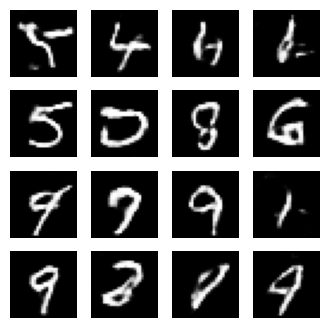

In [21]:
gen_loss_history = []
disc_loss_history = []
train(train_dataset, EPOCHS)

This cell initializes two empty lists, `gen_loss_history` and `disc_loss_history`, which will store the average generator and discriminator loss values for each training epoch, respectively. It then calls the `train()` function, passing the `train_dataset` and the total `EPOCHS` (50) to start the entire GAN training process. After this cell executes, the GAN will be fully trained, and loss histories will be populated.

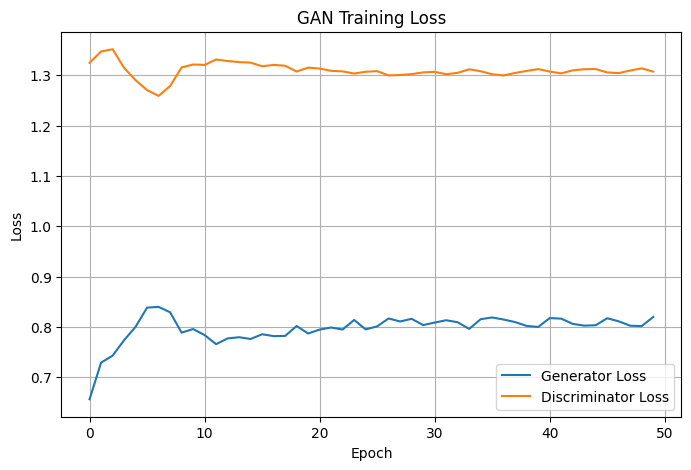

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(gen_loss_history, label='Generator Loss')
plt.plot(disc_loss_history, label='Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GAN Training Loss')
plt.legend()
plt.grid(True)
plt.show()


This cell generates and displays a plot of the generator and discriminator loss curves over the training epochs:
- It creates a figure with a specified size.
- `plt.plot()` is used to draw lines for `gen_loss_history` and `disc_loss_history`.
- Labels are added for the x-axis ('Epoch'), y-axis ('Loss'), and a title ('GAN Training Loss').
- A legend is included to distinguish between generator and discriminator losses.
- A grid is added for better readability.
- `plt.show()` displays the generated plot.

### Generated Images

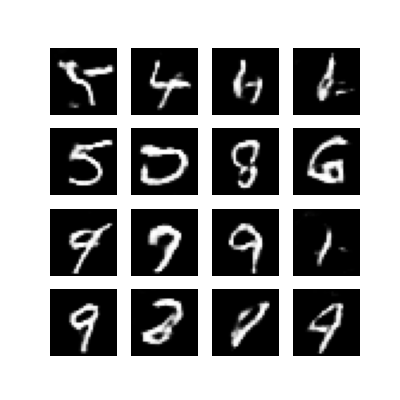

In [24]:
from IPython.display import Image
Image(filename='./image_at_epoch_0050.png')

### Conclusion

This notebook successfully implements and trains a Generative Adversarial Network (GAN) using TensorFlow/Keras to generate handwritten digit images from the MNIST dataset. The generator and discriminator architectures follow the specified guidelines, and the model is trained for 50 epochs. The loss curves show the training progress of both networks, and the generated images demonstrate the GAN's ability to produce realistic-looking digits.